# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
from pathlib import Path
import itertools
import string
import operator
import functools

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import numpy as np

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM PORNO
print(' '.join(
    functools.reduce(operator.add, p)
    for p in itertools.product(string.ascii_uppercase, repeat=3)
    if len(set(p)) == 2
))

AAB AAC AAD AAE AAF AAG AAH AAI AAJ AAK AAL AAM AAN AAO AAP AAQ AAR AAS AAT AAU AAV AAW AAX AAY AAZ ABA ABB ACA ACC ADA ADD AEA AEE AFA AFF AGA AGG AHA AHH AIA AII AJA AJJ AKA AKK ALA ALL AMA AMM ANA ANN AOA AOO APA APP AQA AQQ ARA ARR ASA ASS ATA ATT AUA AUU AVA AVV AWA AWW AXA AXX AYA AYY AZA AZZ BAA BAB BBA BBC BBD BBE BBF BBG BBH BBI BBJ BBK BBL BBM BBN BBO BBP BBQ BBR BBS BBT BBU BBV BBW BBX BBY BBZ BCB BCC BDB BDD BEB BEE BFB BFF BGB BGG BHB BHH BIB BII BJB BJJ BKB BKK BLB BLL BMB BMM BNB BNN BOB BOO BPB BPP BQB BQQ BRB BRR BSB BSS BTB BTT BUB BUU BVB BVV BWB BWW BXB BXX BYB BYY BZB BZZ CAA CAC CBB CBC CCA CCB CCD CCE CCF CCG CCH CCI CCJ CCK CCL CCM CCN CCO CCP CCQ CCR CCS CCT CCU CCV CCW CCX CCY CCZ CDC CDD CEC CEE CFC CFF CGC CGG CHC CHH CIC CII CJC CJJ CKC CKK CLC CLL CMC CMM CNC CNN COC COO CPC CPP CQC CQQ CRC CRR CSC CSS CTC CTT CUC CUU CVC CVV CWC CWW CXC CXX CYC CYY CZC CZZ DAA DAD DBB DBD DCC DCD DDA DDB DDC DDE DDF DDG DDH DDI DDJ DDK DDL DDM DDN DDO DDP DDQ DDR DDS DDT 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

23

In [4]:
reports_paths.sort_values(ascending=False).head()

1     data/cash_app_report_1784210976224.csv
18    data/cash_app_report_1784124129155.csv
17    data/cash_app_report_1783786366452.csv
21    data/cash_app_report_1783720643125.csv
5     data/cash_app_report_1783629391249.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1784210976224.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-16 09:39:33 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BND,$72.70,0.137550,COMPLETE,$10 Purchase of Vanguard Total Bond Market ETF,NaN,Cash Balance
1,2026-07-16 09:37:48 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,UNFI,$49.44,0.202270,COMPLETE,$10 Purchase of United Natural Foods,NaN,Cash Balance
2,2026-07-16 09:37:19 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,IBM,$206.44,0.048440,COMPLETE,$10 Purchase of IBM,NaN,Cash Balance
3,2026-07-16 09:36:49 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,JEPI,$56.74,0.176240,COMPLETE,$10 Purchase of JPMorgan Equity Premium Income...,NaN,Cash Balance
4,2026-07-16 09:35:57 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,TSLA,$388.42,0.025740,COMPLETE,$10 Purchase of Tesla,NaN,Cash Balance
5,2026-07-16 09:35:28 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,RDDT,$195.04,0.025630,COMPLETE,$5 Purchase of Reddit,NaN,Cash Balance
6,2026-07-16 09:34:38 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BSV,$77.67,0.128750,COMPLETE,$10 Purchase of Vanguard Short Term Bond ETF,NaN,Cash Balance
7,2026-07-16 09:33:45 EDT,NaN,NaN,USD,$6.12,$0.00,$6.12,WEN,$7.51,0.814050,COMPLETE,$6.12 Sale of Wendy's,NaN,Cash Balance
8,2026-07-16 09:33:18 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,GOOGL,$371.77,0.026890,COMPLETE,$10 Purchase of Alphabet Inc. Class A,NaN,Cash Balance
9,2026-07-16 09:31:06 EDT,NaN,Bitcoin Sell,USD,$9.00,-$0.18,$8.82,BTC,"$63,792.03",0.000141,COMPLETE,sale of BTC 0.00014108,NaN,Cash Balance


In [7]:
data_raw.shape

(737, 14)

In [8]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
330,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
114,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
201,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
86,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
115,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
199,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
165,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
265,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
119,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
31,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [9]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,599.0,0.2,0.0,0.0,0.1,0.2,4.5


In [10]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
734,2022-11-28 15:28:53+00:00,-20.00,-20.00,NaN,0.000000,0.00,NaN,P2P,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
721,2026-05-27 00:56:27+00:00,100.00,100.00,NaN,0.000000,0.00,NaN,Deposits,USD,NaN,Visa debit 5895,FAILED,Add Cash,NaN
477,2026-06-03 13:48:39+00:00,-10.00,-10.00,412.63,0.024230,0.00,DELL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Dell Technologies,NaN
400,2026-06-03 19:32:10+00:00,-10.00,-10.00,27.05,0.369690,0.00,WBD,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Warner Bros. Discovery,NaN
384,2026-06-03 19:43:16+00:00,-10.00,-10.00,82.16,0.121710,0.00,GM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of General Motors,NaN
282,2026-06-16 13:30:01+00:00,-10.00,-10.00,248.03,0.040310,0.00,AMZN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Amazon,NaN
197,2026-06-18 17:16:31+00:00,-10.00,-10.00,42.70,0.234210,0.00,YUMC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Yum China,NaN
149,2026-06-25 04:00:00+00:00,0.08,0.08,NaN,0.000000,0.00,QCOM,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.08 Dividend from Qualcomm,NaN
42,2026-07-10 13:30:21+00:00,-5.00,-5.00,662.62,0.007540,0.00,META,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Meta,NaN
9,2026-07-16 13:31:06+00:00,8.82,9.00,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN


In [11]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
51,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
730,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
731,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
732,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
734,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
735,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
736,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


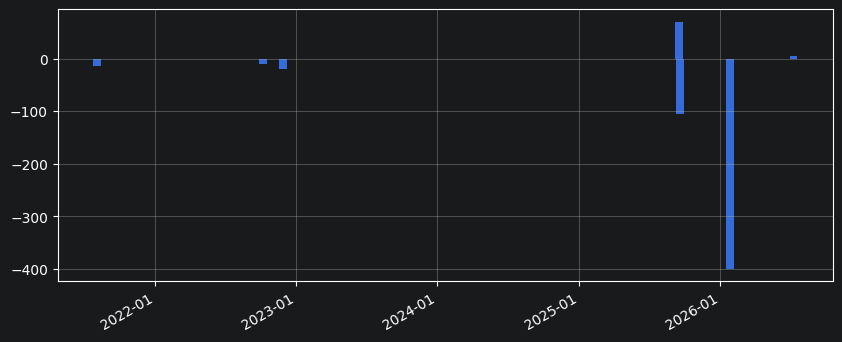

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [13]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,737.00,737.00,599.00,737.00,734.00
mean,-0.05,-0.04,4092.88,0.14,-0.01
std,36.80,36.80,15997.18,0.32,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,59.48,0.01,0.00
50%,-10.00,-10.00,133.27,0.05,0.00
75%,-1.00,-1.00,303.73,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [14]:
data.nunique().sort_values(ascending=False)

asset_price     590
asset_amount    586
date            584
notes           414
asset_type      170
amount           62
net_amount       61
trans_type       10
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [15]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    515
Deposits                      68
Stock Sell                    50
Stock Dividends               47
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,515,10.34,1.00,10.00,10.00,10.00,50.00
Deposits,68,88.76,1.00,50.00,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Stock Dividends,47,0.09,0.01,0.04,0.07,0.14,0.30
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      14
JPM      13
ORCL     13
AMZN     12
WFC      12
META     12
V        10
MCD      10
PZZA     10
GOOGL     9
NFLX      9
VONV      9
DELL      9
DOW       8
MSFT      8
GOOG      8
UBER      8
VOO       7
VMBS      7
FISV      7
HOOD      7
UHAL      6
COIN      6
TGT       6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

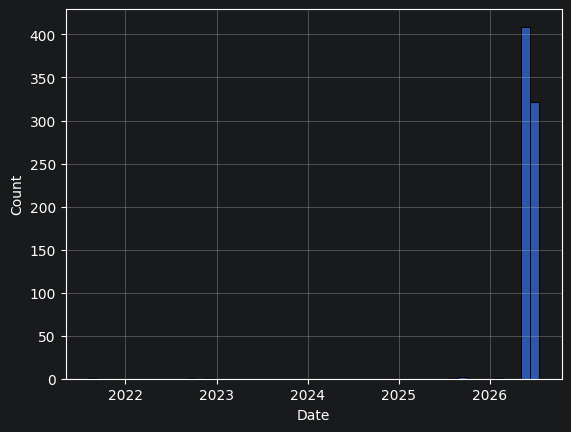

In [18]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [19]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-13,2026-05-27,2026-05-30,2026-06-03,2026-06-04,2026-06-22,2026-07-02,2026-07-10,2026-07-16


In [20]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,13,-110.00,"(-10.0, -5.0)",2
JPM,13,-80.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [21]:
data['currency'].value_counts()

currency
USD    737
Name: count, dtype: int64

In [22]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    515
Deposits                      68
Stock Sell                    50
Stock Dividends               47
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [23]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,10,515,47,50,646
BTC,24,10,0,0,0,34
XYZ,0,0,13,0,1,14
JPM,0,0,11,0,2,13
ORCL,0,0,13,0,0,13
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
AMZN,0,0,12,0,0,12
PZZA,0,0,9,0,1,10


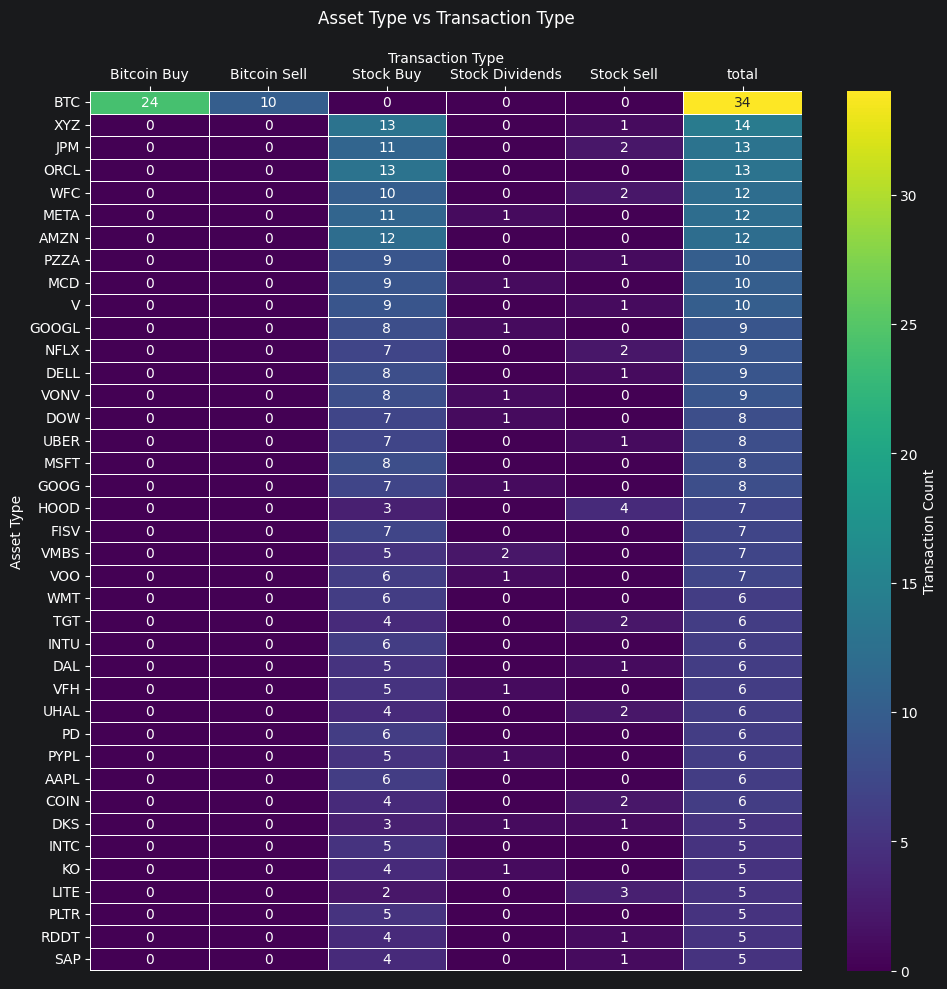

In [24]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [25]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
9,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
33,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
39,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
60,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
72,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


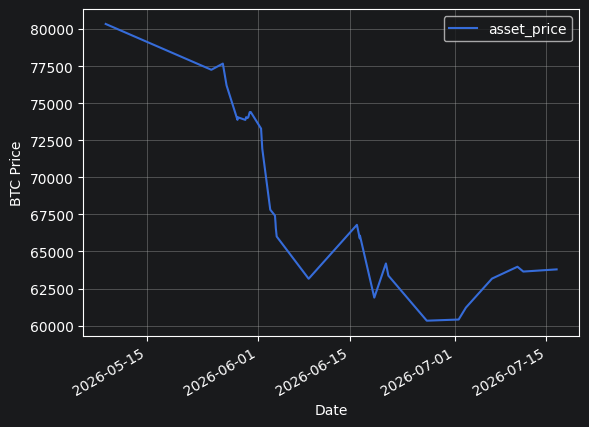

In [26]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [27]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [28]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [29]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [30]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [31]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [32]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

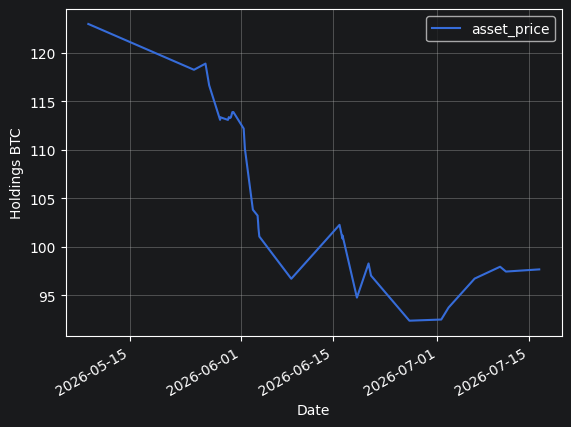

In [33]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [34]:
data_btc['asset_price'] * data_btc['asset_amount']

9       8.999780
33      9.999987
39      9.999926
60      9.999928
72     20.000229
100     9.800290
137     4.900090
192    10.000046
194     4.899747
203    19.999846
285     5.000156
286     4.999899
289     4.900240
325    19.999798
405     9.799846
432     9.800287
456     0.980144
553     9.800221
564     0.979969
581     9.799652
639     4.900136
641     9.799865
644     4.900112
645     9.799903
649     9.799965
653    24.500200
660    24.499951
664    24.500084
683     9.799731
687     9.800031
710    24.499991
727     9.799898
728     4.900356
729     9.799819
dtype: float64

In [35]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
55,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
136,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
165,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
247,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
292,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
340,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
416,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
428,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
441,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
479,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


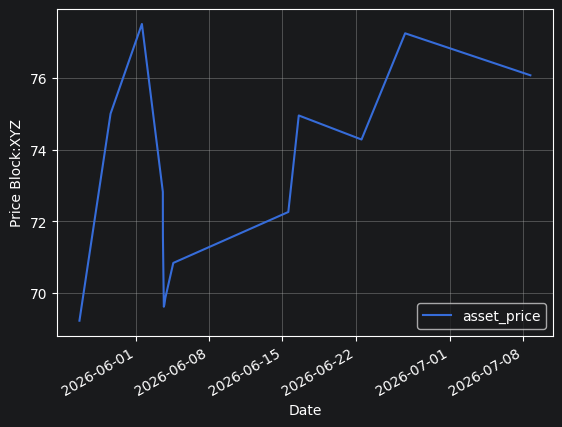

In [36]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [37]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     14
ORCL    13
JPM     13
WFC     12
        ..
SHOP     1
SLAB     1
SNAP     1
CBRS     1
ZG       1
Name: amount, Length: 170, dtype: int64

In [38]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [39]:
data['asset_amount'].describe()

count    737.000000
mean       0.137891
std        0.322187
min        0.000000
25%        0.007980
50%        0.045310
75%        0.127390
max        4.509170
Name: asset_amount, dtype: float64

In [40]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
129,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
202,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
466,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
591,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [41]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-02 16:50:38+00:00,10.217560,0.000000,0.000000,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,0.000000,19.992722,0.0,93.073427,0.000000,0.000000,0.000000,0.000000
2026-06-03 13:30:11+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-03 15:53:29+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,27.762524,0.0,109.742791,19.945984,9.953370,0.000000,0.000000
2026-06-04 13:30:07+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-08 16:33:33+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-10 13:30:05+00:00,28.691891,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:09:36+00:00,28.691891,9.999493,16.180396,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-24 13:30:02+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,26.856968,75.498388,23.724046,27.762524,0.0,171.057249,42.997334,19.954137,9.999727,9.999925
2026-06-26 17:43:48+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,26.856968,75.498388,23.724046,27.762524,0.0,181.056739,42.997334,19.954137,9.999727,9.999925


In [42]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(4173.353062300001)

In [43]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    212.311076
XYZ     188.313567
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-16 13:39:33+00:00, dtype: float64

In [44]:
asset_holding_time_last.tail()

asset_type
VBR    0.000000e+00
VDC    0.000000e+00
OXY    0.000000e+00
WEN   -8.337775e-16
BTC             NaN
Name: 2026-07-16 13:39:33+00:00, dtype: float64

In [45]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AVGO', 'BBEU', 'BIV', 'BNDX', 'CRM', 'CXSE', 'DKS',
       'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'KO', 'KWEB', 'LECO', 'NOBL',
       'NVDA', 'OWL', 'OXY', 'POR', 'PSKY', 'QCOM', 'RUM', 'RUN', 'TSM', 'VBR',
       'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG', 'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [46]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
466,ADP,$10 Purchase of Automatic Data Processing
591,ADP,$10 Purchase of Automatic Data Processing
129,ADP,$0.15 Dividend from Automatic Data Processing
202,ADP,$10 Purchase of Automatic Data Processing
83,ALKT,$20.89 Sale of Alkami Technology
...,...,...
69,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
224,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
628,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
154,XLB,$0.04 Dividend from Materials Select Sector SPDR


In [47]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:35:57+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:36:49+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:37:19+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:37:48+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:39:33+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396


In [48]:
asset_price_rel.iloc[-1].describe()

count    1.690000e+02
mean     5.917160e-03
std      7.365791e-03
min     -1.997860e-19
25%      2.394971e-03
50%      4.124187e-03
75%      7.218673e-03
max      5.087302e-02
Name: 2026-07-16 13:39:33+00:00, dtype: float64

In [49]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.050873
XYZ     0.045123
DELL    0.028258
MCD     0.023485
UBER    0.023043
Name: 2026-07-16 13:39:33+00:00, dtype: float64

In [50]:
asset_price_rel_last.tail()

asset_type
VBR    0.000000e+00
VDC    0.000000e+00
OXY    0.000000e+00
WEN   -1.997860e-19
BTC             NaN
Name: 2026-07-16 13:39:33+00:00, dtype: float64

<Axes: ylabel='Frequency'>

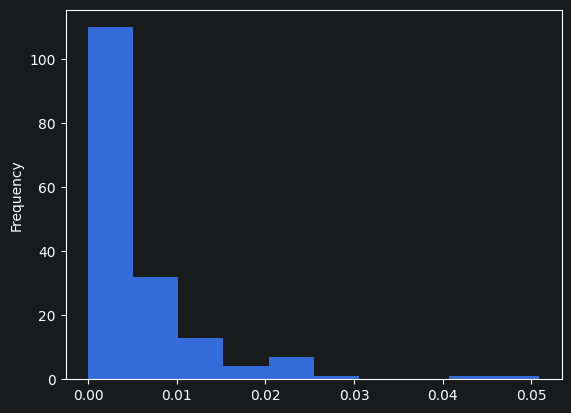

In [51]:
asset_price_rel_last.plot.hist()

In [52]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:35:57+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:36:49+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:37:19+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:37:48+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396
2026-07-16 13:39:33+00:00,0.014691,0.002396,0.003877,0.004404,0.0,0.002396,0.0,0.005044,0.002167,0.007205,...,-1.997860e-19,0.015144,0.005685,0.014162,0.0,0.045123,0.012699,0.004781,0.002396,0.002396


In [53]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-10 13:30:05+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 16:15:42+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 15:51:44+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 15:42:08+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-16 13:30:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 18:53:08+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 18:14:25+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 18:57:59+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-10 13:30:05+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-03 16:15:42+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.005633,1.000000,1.000000,1.0,1.0
2026-06-16 15:51:44+00:00,1.018386,1.0,0.901125,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-01 13:30:02+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-06-16 15:42:08+00:00,1.018386,1.0,0.901125,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-07-16 13:30:07+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.124661,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-15 18:53:08+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-02 18:14:25+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-22 18:57:59+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

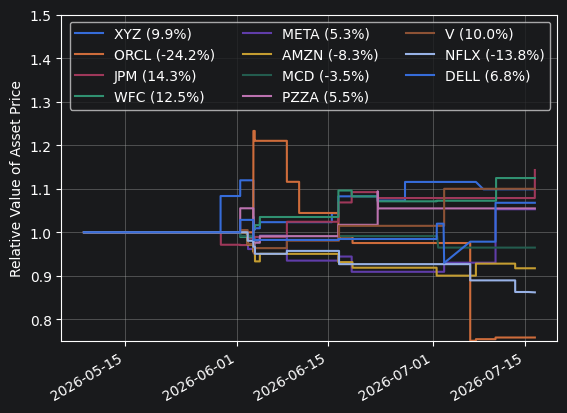

In [55]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.75, 1.5)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [56]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-16 13:35:57+00:00    1.098801
2026-07-16 13:36:49+00:00    1.098801
2026-07-16 13:37:19+00:00    1.098801
2026-07-16 13:37:48+00:00    1.098801
2026-07-16 13:39:33+00:00    1.098801
Name: XYZ, Length: 473, dtype: float64

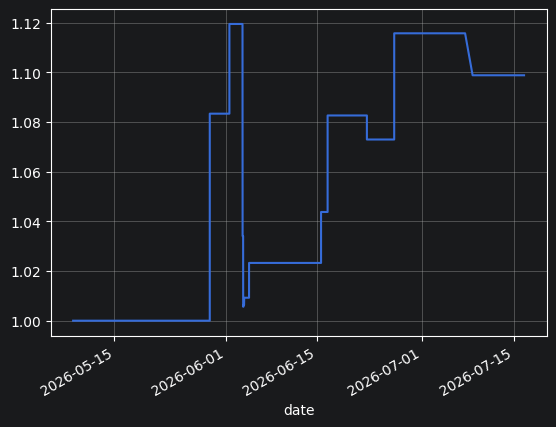

In [57]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [58]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
23,2026-07-15,0.03,LECO,$0.03 Dividend from Lincoln Electric
25,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
26,2026-07-15,0.11,POR,$0.11 Dividend from Portland General Electric ...
24,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
52,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
56,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
66,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
67,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
68,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
69,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF


In [59]:
div_data['amount'].sum()

np.float64(4.34)

In [60]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
141,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
126,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
148,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
287,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
144,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
138,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
127,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
139,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
25,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
158,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...


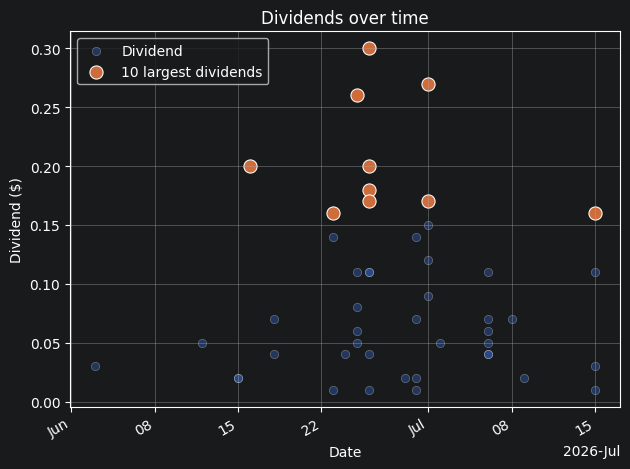

In [61]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [62]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
436,2026-06-03 15:53:29+00:00,-10.00,54.44,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
442,2026-06-03 15:49:42+00:00,-10.00,124.12,$10 Purchase of Vanguard Financials ETF,VFH
0,2026-07-16 13:39:33+00:00,-10.00,72.70,$10 Purchase of Vanguard Total Bond Market ETF,BND
499,2026-06-03 13:30:16+00:00,-10.00,697.19,$10 Purchase of Vanguard S&P 500 ETF,VOO
142,2026-06-26 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Health Care ETF,VHT
507,2026-06-03 13:30:12+00:00,-1.00,46.56,$1 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
498,2026-06-03 13:30:16+00:00,-10.00,104.82,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
261,2026-06-16 13:30:12+00:00,-5.00,107.50,$5 Purchase of Vanguard Russell 1000 Value ETF,VONV
208,2026-06-18 17:09:36+00:00,10.00,96.10,$10 Sale of Vanguard Real Estate ETF,VNQ
181,2026-06-22 13:30:11+00:00,-5.00,106.62,$5 Purchase of Vanguard Russell 1000 Value ETF,VONV


In [63]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
Name: count, dtype: int64

In [64]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
436,2026-06-03 15:53:29+00:00,-10.00,54.44,VGLT,Vanguard Long-Treasury ETF
442,2026-06-03 15:49:42+00:00,-10.00,124.12,VFH,Vanguard Financials ETF
0,2026-07-16 13:39:33+00:00,-10.00,72.70,BND,Vanguard Total Bond Market ETF
499,2026-06-03 13:30:16+00:00,-10.00,697.19,VOO,Vanguard S&P 500 ETF
142,2026-06-26 04:00:00+00:00,0.11,NaN,VHT,NaN
507,2026-06-03 13:30:12+00:00,-1.00,46.56,VMBS,Vanguard Mortgage-Backed Securities ETF
498,2026-06-03 13:30:16+00:00,-10.00,104.82,VONV,Vanguard Russell 1000 Value ETF
261,2026-06-16 13:30:12+00:00,-5.00,107.50,VONV,Vanguard Russell 1000 Value ETF
208,2026-06-18 17:09:36+00:00,10.00,96.10,VNQ,NaN
181,2026-06-22 13:30:11+00:00,-5.00,106.62,VONV,Vanguard Russell 1000 Value ETF


In [65]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           6
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VGLT        Vanguard Long-Treasury ETF                     3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VCR         Vanguard Consumer Discretionary ETF            3
VHT         Vanguard Health Care ETF                       3
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
BIV         Vanguard Intermediate Term Bond ETF            2
BND         Vanguard Total Bond Market ETF                 2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VBR         Small Cap Value ETF Vanguard                   2
BSV         Vanguard Short Te

In [66]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VFH,VDE,VGLT,VCR,VNQ,VHT,VSS,BIV,BNDX,VTEB,VBR,VDC,VONG,BND,BSV
date,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

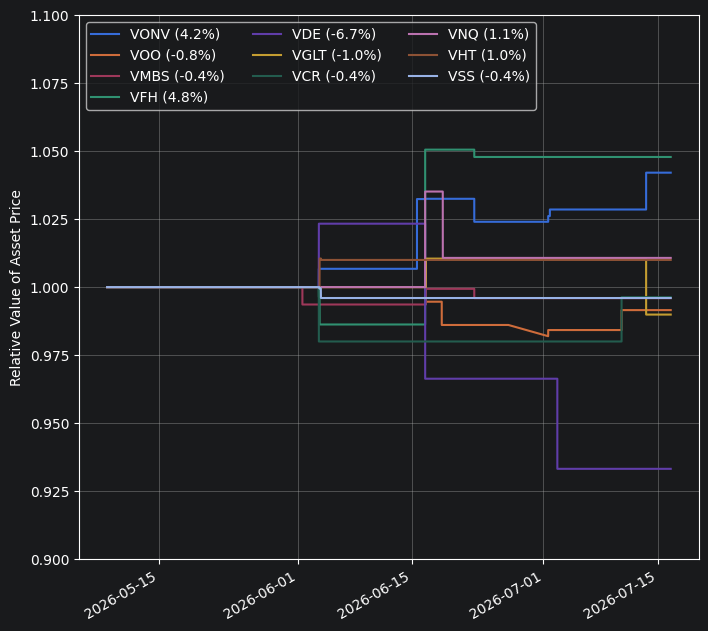

In [68]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [69]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
21,2026-07-16 09:35:34+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
34,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
50,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
91,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
116,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
721,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
722,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
723,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
724,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [70]:
data_deposits['net_amount'].sum()

np.float64(6035.96)

In [71]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,68.0,88.764118,48.890425,1.0,50.0,100.0,100.0,200.0


In [72]:
data_deposits['net_amount'].cumsum()

21      100.00
34      200.00
50      300.00
91      400.00
116     500.00
        ...   
721    5930.96
722    5940.96
723    5990.96
724    6010.96
725    6035.96
Name: net_amount, Length: 68, dtype: float64

In [73]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
725,2026-05-26 19:39:34+00:00,25.00
724,2026-05-26 21:58:29+00:00,45.00
723,2026-05-27 00:43:01+00:00,95.00
722,2026-05-27 00:56:05+00:00,105.00
721,2026-05-27 00:56:27+00:00,205.00
...,...,...
116,2026-07-01 13:41:36+00:00,5635.96
91,2026-07-01 20:14:16+00:00,5735.96
50,2026-07-10 13:17:39+00:00,5835.96
34,2026-07-10 21:11:17+00:00,5935.96


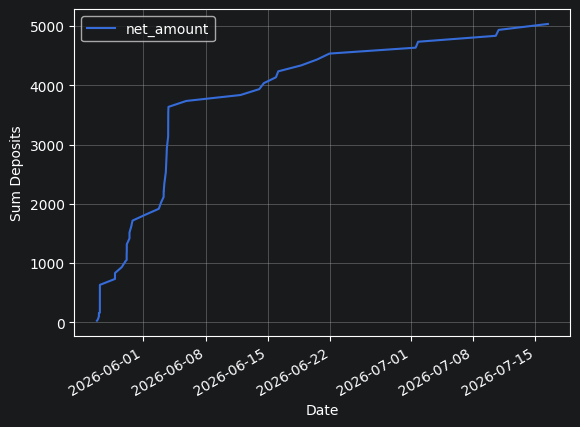

In [74]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [76]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4700.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64